# SS-GAD vector-field gallery

This companion notebook contains several **visual encodings** of the same local fields on the four-well potential. It does not replace the main explanation notebook.

The goal is diagnostic clarity:

- distinguish the policies visually;
- make the hard (lambda_2=0) switching boundary visible;
- make the lowest-mode tie (lambda_1=lambda_2) visible;
- distinguish a true discontinuity from a merely sharp but continuous change.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, hsv_to_rgb

plt.rcParams.update({"figure.dpi":120,"font.size":9,"axes.spines.top":False,"axes.spines.right":False})
COLORS={"ordinary":"#777777","hard":"#D55E00","lambda2":"#CC79A7","competitive":"#0072B2","cs2":"#009E73"}
LABELS={"ordinary":"Ordinary GAD","hard":"Hard descent-then-GAD", "lambda2":r"Soft $lambda_2$ gate",
        "competitive":"Competitive GAD","cs2":"CS²-GAD"}

def grad(q):
    x,y=q; return np.array([4*x*(x*x-1),4*y*(y*y-1)],float)
def hess(q):
    x,y=q; return np.diag([12*x*x-4,12*y*y-4])
def sigmoid(x): return 1/(1+np.exp(-np.clip(x,-60,60)))

def raw_field(q, kind, tau=.18):
    lam,U=np.linalg.eigh(hess(q)); c=U.T@grad(q); scale=max(np.sqrt(np.mean(lam**2)),1e-12)
    z=lam/(tau*scale); p=np.exp(-z-z.max()); p/=p.sum(); neg=sigmoid(-z); w2=sigmoid(z[1])
    soft=np.sum(p*c*c); extra=np.sum(neg*(1-p)**2*c*c); chi=soft/(soft+extra) if soft+extra else 0.
    if kind=="ordinary": w,r=1.,np.array([1.,0.])
    elif kind=="hard": w,r=float(lam[1]>0),np.array([1.,0.])
    elif kind=="lambda2": w,r=w2,p
    elif kind=="competitive": w,r=w2+(1-w2)*chi,p
    else: w,r=w2+(1-w2)*chi,p/p.max()
    return U@(-(1-2*w*r)*c), lam, w

grid=np.linspace(-1.5,1.5,241); X,Y=np.meshgrid(grid,grid)
L1=np.empty_like(X); L2=np.empty_like(X)
for i in range(len(grid)):
 for j in range(len(grid)):
  ev=np.linalg.eigvalsh(hess((X[i,j],Y[i,j]))); L1[i,j],L2[i,j]=ev


## 1. Fixed-size arrows, with colour for magnitude

Arrow *direction* is normalized, so flat regions remain visible. Arrow *colour* encodes (log_{10}|Phi(q)|). This is the best compact comparison view when different methods have very different magnitudes.

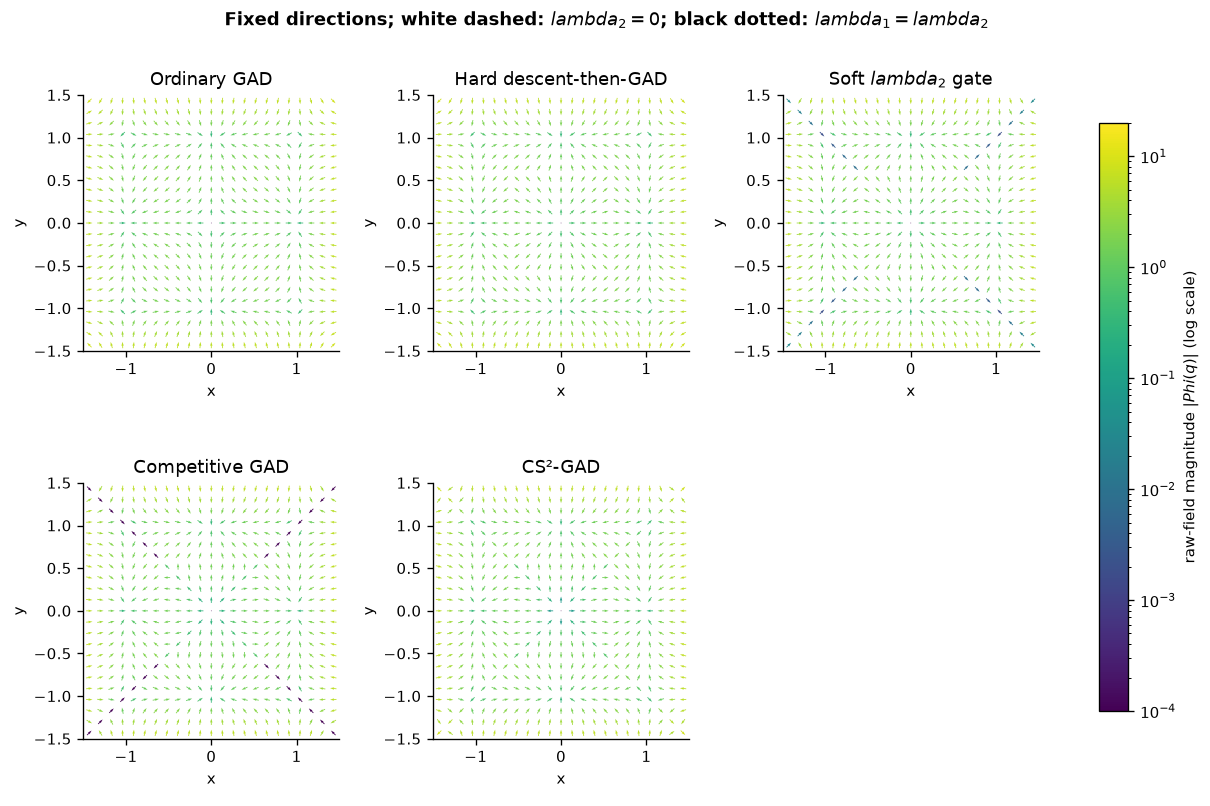

In [2]:
def fixed_arrow_panel(ax, kind, n=23):
    pts=np.linspace(-1.43,1.43,n); PX,PY=np.meshgrid(pts,pts); P=np.c_[PX.ravel(),PY.ravel()]
    V=np.array([raw_field(q,kind)[0] for q in P]); mag=np.linalg.norm(V,axis=1)
    D=V/np.maximum(mag[:,None],1e-12); D*=.075
    sc=ax.quiver(P[:,0],P[:,1],D[:,0],D[:,1],np.maximum(mag,1e-5),cmap="viridis",
                 norm=LogNorm(1e-4,20),angles="xy",scale_units="xy",scale=1,pivot="mid",width=.0032)
    ax.contour(X,Y,L2,levels=[0],colors="white",linestyles="--",linewidths=1.2)
    ax.contour(X,Y,L2-L1,levels=[0],colors="black",linestyles=":",linewidths=.9)
    ax.set(title=LABELS[kind],xlim=(-1.5,1.5),ylim=(-1.5,1.5),aspect="equal",xlabel="x",ylabel="y")
    return sc

fig,axes=plt.subplots(2,3,figsize=(10,6.7),constrained_layout=True)
for ax,kind in zip(axes.flat,("ordinary","hard","lambda2","competitive","cs2")): sc=fixed_arrow_panel(ax,kind)
axes.flat[-1].axis("off")
fig.colorbar(sc,ax=axes.ravel().tolist(),label=r"raw-field magnitude $|Phi(q)|$ (log scale)",shrink=.78)
fig.suptitle(r"Fixed directions; white dashed: $lambda_2=0$; black dotted: $lambda_1=lambda_2$",fontweight="bold")
plt.show()


## 2. A full-resolution direction-and-magnitude image

Here hue is the direction angle (arg(Phi_x+iPhi_y)), while brightness increases with (log|Phi|). Unlike arrows, this makes very thin switching or eigenvalue-crossing structures visible everywhere. The dashed and dotted curves have the same meaning as above.

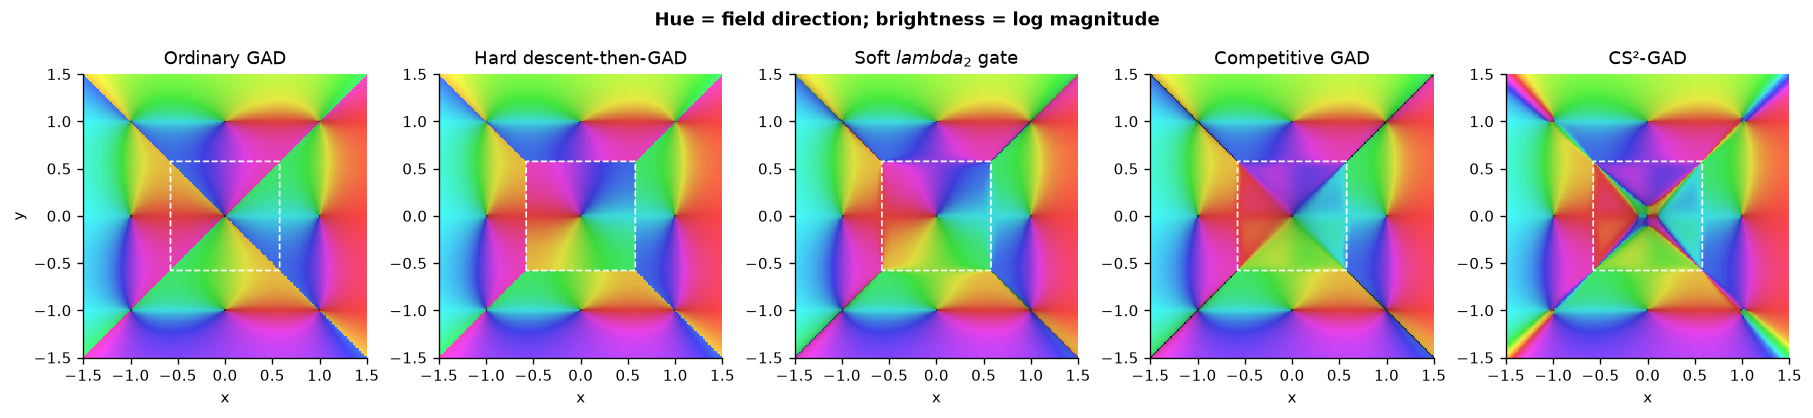

In [3]:
def direction_image(kind):
    V=np.empty(X.shape+(2,))
    for i in range(len(grid)):
     for j in range(len(grid)): V[i,j]=raw_field((X[i,j],Y[i,j]),kind)[0]
    angle=(np.arctan2(V[...,1],V[...,0])+np.pi)/(2*np.pi)
    mag=np.linalg.norm(V,axis=-1)
    value=.18+.82*np.clip((np.log10(mag+1e-6)+4)/5,0,1)
    hsv=np.dstack([angle,np.full_like(value,.72),value])
    return hsv_to_rgb(hsv)

fig,axes=plt.subplots(1,5,figsize=(15,3.4),constrained_layout=True)
for ax,kind in zip(axes,("ordinary","hard","lambda2","competitive","cs2")):
    ax.imshow(direction_image(kind),origin="lower",extent=(-1.5,1.5,-1.5,1.5),interpolation="nearest")
    ax.contour(X,Y,L2,levels=[0],colors="white",linestyles="--",linewidths=1)
    ax.contour(X,Y,L2-L1,levels=[0],colors="black",linestyles=":",linewidths=.8)
    ax.set(title=LABELS[kind],aspect="equal",xlabel="x")
axes[0].set_ylabel("y")
fig.suptitle("Hue = field direction; brightness = log magnitude",fontweight="bold")
plt.show()


## 3. Numerical jump diagnostic

For each field, this map estimates the largest one-grid-step change in the **normalized** field direction. A true hard switch appears as a narrow high-score ridge at (lambda_2=0); a soft gate can be steep but remains continuous. This is a finite-resolution diagnostic, not a proof of differentiability.

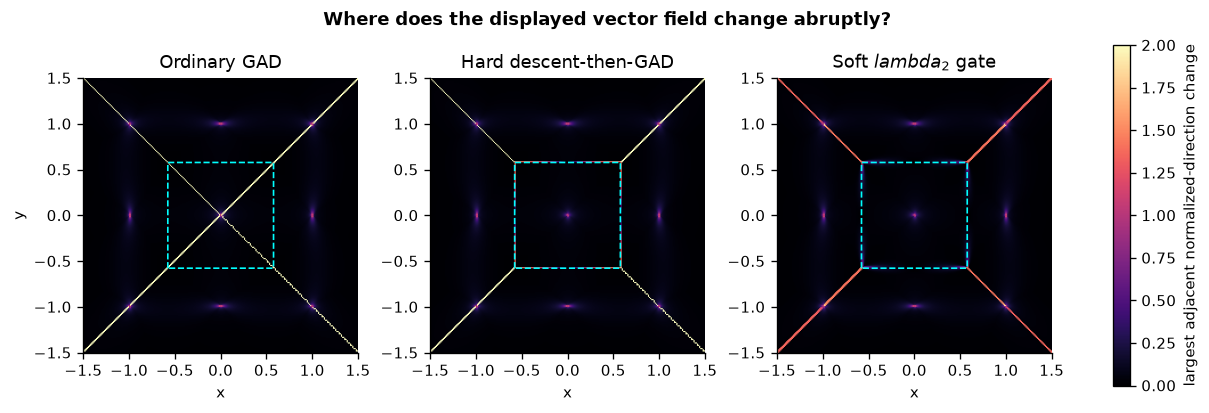

In [4]:
def jump_score(kind):
    V=np.empty(X.shape+(2,))
    for i in range(len(grid)):
     for j in range(len(grid)): V[i,j]=raw_field((X[i,j],Y[i,j]),kind)[0]
    U=V/np.maximum(np.linalg.norm(V,axis=-1,keepdims=True),1e-10)
    dx=np.linalg.norm(U[:,1:]-U[:,:-1],axis=-1); dy=np.linalg.norm(U[1:]-U[:-1],axis=-1)
    J=np.zeros(X.shape); J[:,1:]=np.maximum(J[:,1:],dx); J[1:]=np.maximum(J[1:],dy)
    return J

fig,axes=plt.subplots(1,3,figsize=(10,3.4),constrained_layout=True)
for ax,kind in zip(axes,("ordinary","hard","lambda2")):
    im=ax.imshow(jump_score(kind),origin="lower",extent=(-1.5,1.5,-1.5,1.5),vmin=0,vmax=2,cmap="magma")
    ax.contour(X,Y,L2,levels=[0],colors="cyan",linestyles="--",linewidths=1)
    ax.contour(X,Y,L2-L1,levels=[0],colors="white",linestyles=":",linewidths=.8)
    ax.set(title=LABELS[kind],aspect="equal",xlabel="x")
axes[0].set_ylabel("y")
fig.colorbar(im,ax=axes,label="largest adjacent normalized-direction change")
fig.suptitle("Where does the displayed vector field change abruptly?",fontweight="bold")
plt.show()


### Reading guide

- The **hard-gate** field can have a genuine discontinuity at the dashed (lambda_2=0) boundary because its gate jumps from (0) to (1).
- The **soft (lambda_2)**, competitive, and CS² gates are continuous in the gate value; their transitions can still be sharp.
- Ordinary rank-one GAD can be non-unique at the dotted (lambda_1=lambda_2) crossing because the selected lowest eigenvector is not unique there.
- CS² removes the arbitrary one-vector choice from its reflection operator, although ordered-eigenvalue constructions remain piecewise smooth at crossings.
